In [73]:
library(pheatmap)
library(RColorBrewer)
library(dplyr)
library(tidyverse)
library(ggpubr)
library(tidyr)

In [74]:
C2peaks_data <- read.table('C2_peaks.FC1.5.center200.states.matrix',header=T,sep="\t",row.names = 1)
C3peaks_data <- read.table('C3_peaks.FC1.5.center200.states.matrix',header=T,sep="\t",row.names = 1)

In [75]:
C2peaks_data  %>% head(n =5)

,U3008,U3013,U3020,U3024,U3027,U3031,U3033,U3034,U3035,U3037,⋯,U3137,U3140,U3155,U3167,U3173,U3198,U3202,U3230,U3308,U3429
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr6_12348435_12349253,Low2,Low2,EnhPoised2,EnhA1,Low2,EnhPrimed,Low2,Low2,EnhPoised2,EnhA2,⋯,EnhA2,EnhA2,EnhA2,EnhA2,EnhA2,EnhPoised2,EnhPoised1,Low2,Low3,Low2
chr17_65132113_65132313,Low3,Low3,EnhBivalent,EnhPrimed,Low2,EnhPrimed,Low3,EnhPrimed,Low3,EnhPrimed,⋯,TxFlank,EnhPrimed,EnhA2,EnhPoised2,EnhPoised2,TxFlank,EnhPoised2,EnhA1,TssFlank,Low2
chr3_155498185_155498385,EnhA2,EnhPoised2,EnhA1,EnhA2,EnhA2,EnhA2,EnhA2,EnhA2,EnhA2,EnhA2,⋯,EnhA2,EnhA2,EnhA1,EnhA2,EnhA2,EnhA1,EnhA2,EnhA1,EnhA2,EnhA1
chr10_4775959_4776159,EnhPoised2,Low2,EnhPoised2,EnhA2,TxFlank,EnhA2,Low2,EnhA2,Low2,EnhA1,⋯,EnhPoised2,EnhA2,EnhA2,EnhPoised2,EnhA2,Low2,EnhPoised1,Low2,Low2,EnhPoised2
chr3_43708105_43708305,EnhPoised2,Low2,EnhPoised2,EnhPoised2,EnhPoised2,EnhPrimed,Low2,EnhPrimed,EnhPoised2,EnhA2,⋯,EnhA2,EnhA2,EnhA2,EnhPrimed,EnhA2,EnhPoised2,EnhPoised2,EnhPrimed,EnhPoised2,EnhPoised2


In [76]:
Allpeaks_data <- read.table('all.peaks.clean.center200.states.matrix',header=T,sep="\t",row.names = 1)

In [77]:
phe <- readRDS("phe3.Rds")
phe %>% filter(footprint=='C2') %>% rownames() -> C2_names
phe %>% filter(footprint=='C3') %>% rownames() -> C3_names

In [78]:
states =  c("ActiveTSS","TssFlank","TssFlankD","TxFlank","EnhA1",  "EnhA2","EnhPoised1","EnhPrimed","EnhPoised2","EnhBivalent","ReprPC", "Low1","Low2","Low3","Low4")

### calculate the frequency

In [79]:
levels = c('ActiveTSS','TssFlank','TxFlank','TssFlankD','EnhA1','EnhA2','EnhPoised1','EnhPoised2','EnhPrimed',
           'EnhBivalent','ReprPC','Low1','Low2','Low3','Low4')

In [80]:
count_matrix <- sapply(C2peaks_data, function(col) {
  tbl <- table(factor(col, levels = levels))
  as.numeric(tbl)
})

In [81]:
rownames(count_matrix) <- levels
C2_peak_freq <- sweep(count_matrix, 2, colSums(count_matrix), FUN = "/")

In [82]:
count_matrix2 <- sapply(C3peaks_data, function(col) {
  tbl <- table(factor(col, levels = levels))
  as.numeric(tbl)
})

In [83]:
rownames(count_matrix2) <- levels
C3_peak_freq <- sweep(count_matrix2, 2, colSums(count_matrix2), FUN = "/")

In [84]:
count_matrix3 <- sapply(Allpeaks_data, function(col) {
  tbl <- table(factor(col, levels = levels))
  as.numeric(tbl)
})

In [85]:
rownames(count_matrix3) <- levels
All_peak_freq <- sweep(count_matrix3, 2, colSums(count_matrix3), FUN = "/")

In [86]:
C2_peak_freq[!C2_peak_freq  %>% rownames()  %>% str_detect('Low'),C2_names] -> C2_peak_freq2_inC2
C2_peak_freq[!C2_peak_freq  %>% rownames()  %>% str_detect('Low'),C3_names] -> C2_peak_freq2_inC3

C3_peak_freq[!C3_peak_freq  %>% rownames()  %>% str_detect('Low'),C2_names] -> C3_peak_freq2_inC2
C3_peak_freq[!C3_peak_freq  %>% rownames()  %>% str_detect('Low'),C3_names] -> C3_peak_freq2_inC3

In [87]:
All_peak_freq[!All_peak_freq  %>% rownames()  %>% str_detect('Low'),] -> All_peak_freq2

In [88]:
apply(C2_peak_freq2_inC2, 2, function(x) x / sum(x)) -> C2_peak_freq3_inC2
apply(C2_peak_freq2_inC3, 2, function(x) x / sum(x)) -> C2_peak_freq3_inC3

apply(C3_peak_freq2_inC2, 2, function(x) x / sum(x)) -> C3_peak_freq3_inC2
apply(C3_peak_freq2_inC3, 2, function(x) x / sum(x)) -> C3_peak_freq3_inC3      

In [89]:
apply(All_peak_freq2, 2, function(x) x / sum(x)) -> All_peak_freq3      

In [90]:
states[!states  %>% str_detect('Low')] -> states

## for barplot

In [91]:
data_for_bar <- data.frame(All=rowMeans(All_peak_freq3)[states], 
                           C2inC2=rowMeans(C2_peak_freq3_inC2)[states],
                           C2inC3=rowMeans(C2_peak_freq3_inC3)[states],
                           C3inC2=rowMeans(C3_peak_freq3_inC2)[states],
                           C3inC3=rowMeans(C3_peak_freq3_inC3)[states])

In [92]:
data_for_bar

,All,C2inC2,C2inC3,C3inC2,C3inC3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ActiveTSS,0.091930934,0.0051723542,0.008191188,0.041683907,0.042754009
TssFlank,0.016417732,0.0068010060,0.009414239,0.019946893,0.012461983
TssFlankD,0.005770534,0.0005808579,0.002939949,0.004181914,0.003232607
TxFlank,0.020569653,0.0091254099,0.038110381,0.020499419,0.013229270
EnhA1,0.191841263,0.1310885266,0.103214485,0.137355455,0.175994648
EnhA2,0.232676957,0.3984250805,0.269517324,0.193553096,0.259672844
EnhPoised1,0.072868818,0.0752067260,0.152368079,0.104156686,0.057965114
EnhPrimed,0.150685171,0.2243066004,0.144808961,0.132232683,0.202961051
EnhPoised2,0.117281805,0.1217445573,0.226479772,0.149366420,0.100124407


In [93]:
data_for_bar$states <- states

In [94]:
data_for_bar2 <- pivot_longer(data =data_for_bar,!states, names_to = "Group", values_to = "Proportion" )

In [95]:
data_for_bar$states

[1] "ActiveTSS"   "TssFlank"    "TssFlankD"   "TxFlank"     "EnhA1"      
 [6] "EnhA2"       "EnhPoised1"  "EnhPrimed"   "EnhPoised2"  "EnhBivalent"
[11] "ReprPC"

In [96]:
data_for_bar2$states <- factor(data_for_bar2$states,levels=states)

In [97]:
head(data_for_bar)

,All,C2inC2,C2inC3,C3inC2,C3inC3,states
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ActiveTSS,0.091930934,0.0051723542,0.008191188,0.041683907,0.042754009,ActiveTSS
TssFlank,0.016417732,0.0068010060,0.009414239,0.019946893,0.012461983,TssFlank
TssFlankD,0.005770534,0.0005808579,0.002939949,0.004181914,0.003232607,TssFlankD
TxFlank,0.020569653,0.0091254099,0.038110381,0.020499419,0.013229270,TxFlank
EnhA1,0.191841263,0.1310885266,0.103214485,0.137355455,0.175994648,EnhA1
EnhA2,0.232676957,0.3984250805,0.269517324,0.193553096,0.259672844,EnhA2


In [98]:
data_for_bar2$states 

[1] ActiveTSS   ActiveTSS   ActiveTSS   ActiveTSS   ActiveTSS   TssFlank   
 [7] TssFlank    TssFlank    TssFlank    TssFlank    TssFlankD   TssFlankD  
[13] TssFlankD   TssFlankD   TssFlankD   TxFlank     TxFlank     TxFlank    
[19] TxFlank     TxFlank     EnhA1       EnhA1       EnhA1       EnhA1      
[25] EnhA1       EnhA2       EnhA2       EnhA2       EnhA2       EnhA2      
[31] EnhPoised1  EnhPoised1  EnhPoised1  EnhPoised1  EnhPoised1  EnhPrimed  
[37] EnhPrimed   EnhPrimed   EnhPrimed   EnhPrimed   EnhPoised2  EnhPoised2 
[43] EnhPoised2  EnhPoised2  EnhPoised2  EnhBivalent EnhBivalent EnhBivalent
[49] EnhBivalent EnhBivalent ReprPC      ReprPC      ReprPC      ReprPC     
[55] ReprPC     
11 Levels: ActiveTSS TssFlank TssFlankD TxFlank EnhA1 EnhA2 ... ReprPC

In [99]:
data_for_bar2$states  <- factor(data_for_bar2$states, 
                                 levels = c('ActiveTSS','TssFlank','TssFlankD','TxFlank','EnhA1','EnhA2',
                                            'EnhPoised1','EnhPoised2','EnhPrimed','EnhBivalent','ReprPC'))

In [100]:
saveRDS(data_for_bar2,file ="C2C3_diffPeaks_for_bar.Rds" )

In [101]:
options(repr.plot.height=6,repr.plot.width=4)
p_bar <- ggplot(data = data_for_bar2,aes(x=Group,y=Proportion,fill=states))+
    geom_bar(stat="identity") +theme_bw() +xlab("") +theme(axis.text = element_text(color="black",size=10))+
    scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                                "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#bbbcbb","#8e8e8e",
                               "#727272"))

In [102]:
data_for_bar2  %>% pivot_wider(names_from = Group, values_from = Proportion) -> data_for_bar_writeout

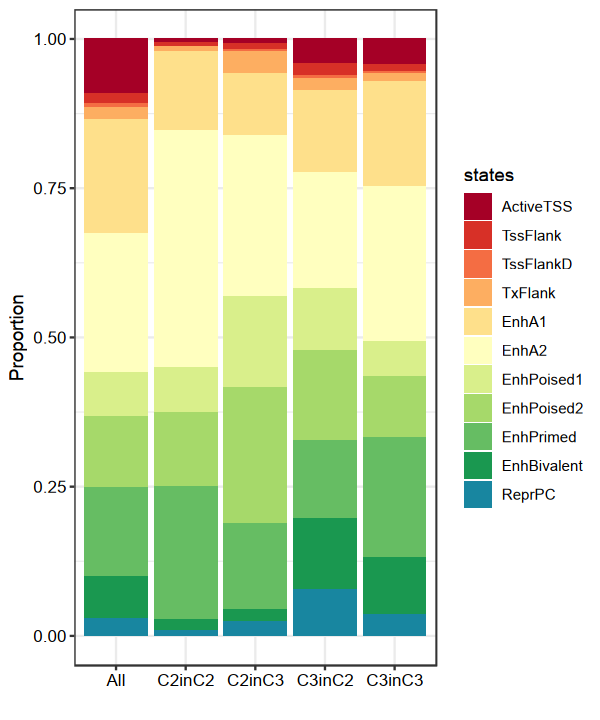

In [103]:
options(repr.plot.height=6,repr.plot.width=5)
p_bar

In [38]:
ggsave(filename = "ATAC_peaks_Proportion_bar.pdf",plot = p_bar,width = 4,height = 6)

### heatmap

In [39]:
C2C3combine_for_bar <- data.frame(C2=C2_peak_freq3_inC2[states,C2_names],
                           C3=C3_peak_freq3_inC3[states,C3_names])

In [40]:
library(corrplot)

corrplot 0.95 loaded



In [41]:
library(ComplexHeatmap)
library(circlize)
library(grid)

Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().



Attaching package: ‘Co

In [42]:
#C2C3combine_for_bar[C2C3combine_for_bar>0.5] = 0.5

In [43]:
options(repr.plot.width = 14, repr.plot.height = 5)
# Define color function
col_fun = circlize::colorRamp2(c(0, 0.3), c("white", "#910F2A"))

# Define the heatmap
ht <- Heatmap(as.matrix(C2C3combine_for_bar), name = "correlation", col = col_fun, rect_gp = gpar(type = "none"), 
    cell_fun = function(j, i, x, y, width, height, fill) {
        grid.rect(x = x, y = y, width = width, height = height, gp = gpar(col = "grey", fill = NA))
        grid.circle(x = x, y = y, r = abs(as.matrix(C2C3combine_for_bar)[i, j]) * 2.5 * min(unit.c(width, height)), 
            gp = gpar(fill = "#910F2A", col = NA))
    }, 
    cluster_rows = FALSE, cluster_columns = FALSE,
    show_row_names = TRUE, show_column_names = TRUE
)

# Create a legend for circle size
circle_sizes <- c(0.1, 0.2, 0.3,0.4,0.5)  # Example values for legend
circle_legends <- Legend(labels = as.character(circle_sizes),
                         title = "Circle Size",
                         type = "points",
                         pch = 21,  # Circle shape
                         legend_gp = gpar(fill = "#910F2A"),  # Circle fill color
                         size = unit(circle_sizes , "cm") # Scale appropriately
)

# Draw heatmap with legend

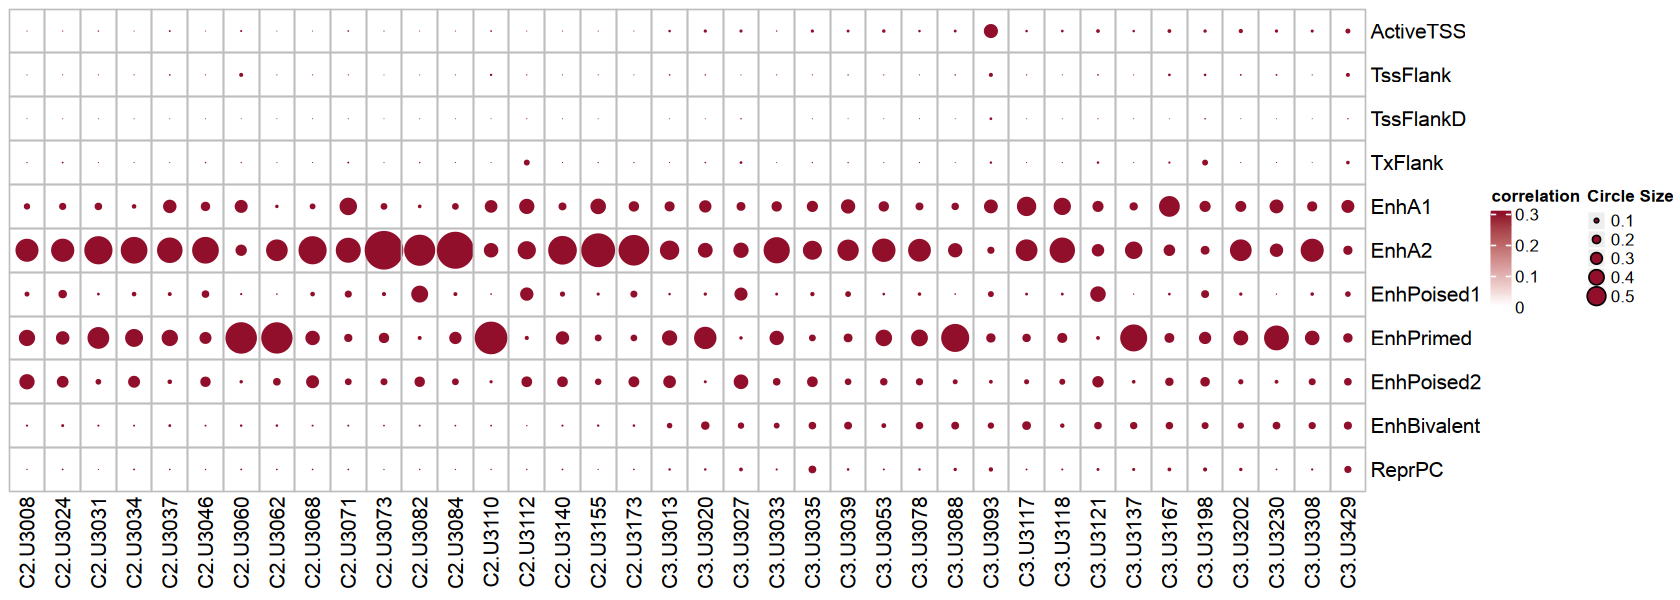

In [44]:
draw(ht, annotation_legend_list = list(circle_legends))

In [39]:
pdf(file = "Heatmap.Proportion.sample.states.pdf",width = 14,height = 5)
draw(ht, annotation_legend_list = list(circle_legends))
dev.off()

pdf 
  2

In [40]:
options(repr.plot.width=12,repr.plot.height = 5)
#C2C3combine_for_bar[C2C3combine_for_bar>0.5] = 0.5
pheatmap::pheatmap(C2C3combine_for_bar,cluster_rows = F,cluster_cols = F,width = 12,height = 5,
        filename = "Heatmap.Proportion.sample.states.alt.pdf",
         colorRampPalette(c("#25527C", "white", "#910F2A"))(100))

## for boxplot

In [45]:
C2_peak_freq2 <- as.data.frame(C2_peak_freq3[states,C2_names])
C3_peak_freq2 <- as.data.frame(C3_peak_freq3[states,C3_names])

In [46]:
C2_peak_freq2$states <- rownames(C2_peak_freq2)
C3_peak_freq2$states <- rownames(C3_peak_freq2)

In [47]:
All_peak_freq <- as.data.frame(All_peak_freq)

In [48]:
All_peak_freq <- All_peak_freq[states,]

In [49]:
All_peak_freq$states <- states

In [50]:
C2_peak_freq2_forbox <- pivot_longer(data =C2_peak_freq2,!states, names_to = "sample", values_to = "Proportion" )
C3_peak_freq2_forbox <- pivot_longer(data =C3_peak_freq2,!states, names_to = "sample", values_to = "Proportion" )
All_peak_freq_forbox <- pivot_longer(data =All_peak_freq,!states, names_to = "sample", values_to = "Proportion" )

In [51]:
C2_peak_freq2_forbox$group <- "C2"
C3_peak_freq2_forbox$group <- "C3"
All_peak_freq_forbox$group <- "All"

In [52]:
rbind(C2_peak_freq2_forbox,C3_peak_freq2_forbox)  -> C2_C3_order_forbox_comb

In [53]:
rbind(All_peak_freq_forbox,C2_peak_freq2_forbox,C3_peak_freq2_forbox)  -> All_C2_C3_order_forbox_comb

In [54]:
head(C2_C3_order_forbox_comb)

states,sample,Proportion,group
<chr>,<chr>,<dbl>,<chr>
ActiveTSS,U3008,0.003057844,C2
ActiveTSS,U3024,0.004204470,C2
ActiveTSS,U3031,0.007583751,C2
ActiveTSS,U3034,0.002149116,C2
ActiveTSS,U3037,0.014915114,C2
ActiveTSS,U3046,0.001882388,C2


In [55]:
C2_C3_order_forbox_comb$states <- factor(C2_C3_order_forbox_comb$states,levels=states)

In [56]:
All_C2_C3_order_forbox_comb$states <- factor(All_C2_C3_order_forbox_comb$states,levels=states)

In [57]:
compare_list <- list(c("C2","C3"))

In [58]:
compare_list2 <- list(c("All","C3"),c("C2","All"),c("C2","C3"))

In [59]:
All_C2_C3_order_forbox_comb$group <- factor(All_C2_C3_order_forbox_comb$group ,levels = c("All","C2","C3"))

In [60]:
saveRDS(All_C2_C3_order_forbox_comb,file = "Diff_forbox_comb.Rds")

In [61]:
openxlsx::write.xlsx(list(All = All_C2_C3_order_forbox_comb,Average = data_for_bar_writeout),rowNames = TRUE,file = "ChromatinStates_Proportion.xlsx")

In [62]:
p1 <- ggboxplot(All_C2_C3_order_forbox_comb,x="group",y="Proportion",add="jitter",add.params=list(shape=21, fill="orange", size=1.5)
         )+geom_signif(comparisons = compare_list2,step_increase = 0.1,map_signif_level = F,test = t.test
                      )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")

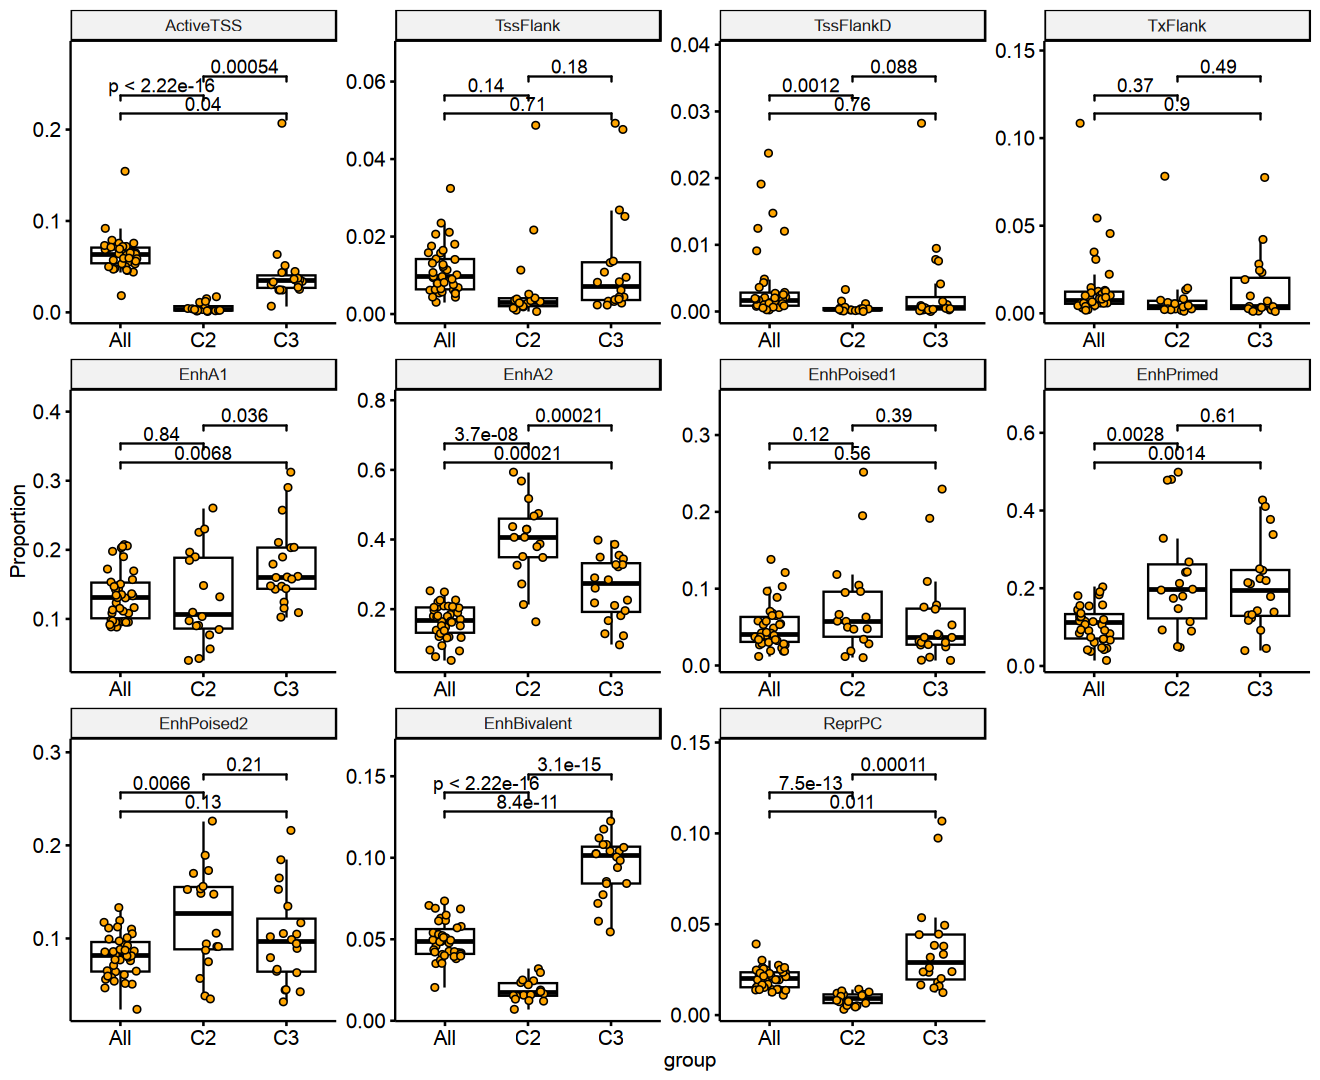

In [63]:
options(repr.plot.height=9,repr.plot.width=11)
p1

In [ ]:
ggsave(filename = "All_C2_C3_peaks_compare_boxplot.pdf",plot =p1 ,width =11 ,height =9 )

In [66]:
head(All_C2_C3_order_forbox_comb)

states,sample,Proportion,group
<fct>,<chr>,<dbl>,<fct>
ActiveTSS,U3008,0.05711455,All
ActiveTSS,U3013,0.05528999,All
ActiveTSS,U3020,0.07131476,All
ActiveTSS,U3024,0.06573375,All
ActiveTSS,U3027,0.05301135,All
ActiveTSS,U3031,0.09188029,All


In [71]:
library(dplyr)

All_C2_C3_order_forbox_comb %>%
  group_by(group,states) %>%
  reframe(
    q0   = quantile(Proportion, 0),
    q25  = quantile(Proportion, 0.25),
    median = quantile(Proportion, 0.5),
    q75  = quantile(Proportion, 0.75),
    q100 = quantile(Proportion, 1)
  )  %>% arrange(states) -> box_stats

In [104]:
openxlsx::write.xlsx(box_stats,file = "Diff_peaks_ChromHMM_stats.xlsx")

### barplot for all

In [45]:
All_peak_freq3 <- as.data.frame(All_peak_freq3)

In [46]:
All_peak_freq3$states <- rownames(All_peak_freq3)

In [47]:
All_peak_freq_bar <- pivot_longer(data =All_peak_freq3,!states, names_to = "Group", values_to = "Proportion" )

In [48]:
c(C3_names,C2_names)

[1] "U3013" "U3020" "U3027" "U3033" "U3035" "U3039" "U3053" "U3078" "U3088"
[10] "U3093" "U3117" "U3118" "U3121" "U3137" "U3167" "U3198" "U3202" "U3230"
[19] "U3308" "U3429" "U3008" "U3024" "U3031" "U3034" "U3037" "U3046" "U3060"
[28] "U3062" "U3068" "U3071" "U3073" "U3082" "U3084" "U3110" "U3112" "U3140"
[37] "U3155" "U3173"

In [49]:
All_peak_freq_bar$Group <- factor(All_peak_freq_bar$Group,levels=c(C2_names,C3_names))

In [56]:
All_peak_freq_bar$states <- factor(All_peak_freq_bar$states,levels = states)

In [70]:
library(ggplot2)
library(ggtext)

# Simulate axis label coloring
All_peak_freq_bar$Group_label <- ifelse(
  as.numeric(factor(All_peak_freq_bar$Group)) <= 18,
  paste0("<span style='color:red;'>", All_peak_freq_bar$Group, "</span>"),
  paste0("<span style='color:blue;'>", All_peak_freq_bar$Group, "</span>")
)
All_peak_freq_bar$Group_label <- factor(All_peak_freq_bar$Group_label, levels = unique(All_peak_freq_bar$Group_label))
# Plot with modified x-axis text color
p_bar_allpeaks <- ggplot(data = All_peak_freq_bar, aes(x = Group_label, y = Proportion, fill = states)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  xlab("") +
  theme(
    axis.text.x = element_markdown(angle = 45, hjust = 1, size = 10),
    axis.text.y = element_text(color = "black", size = 10)
  ) +scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                                "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#bbbcbb","#8e8e8e",
                               "#727272"))

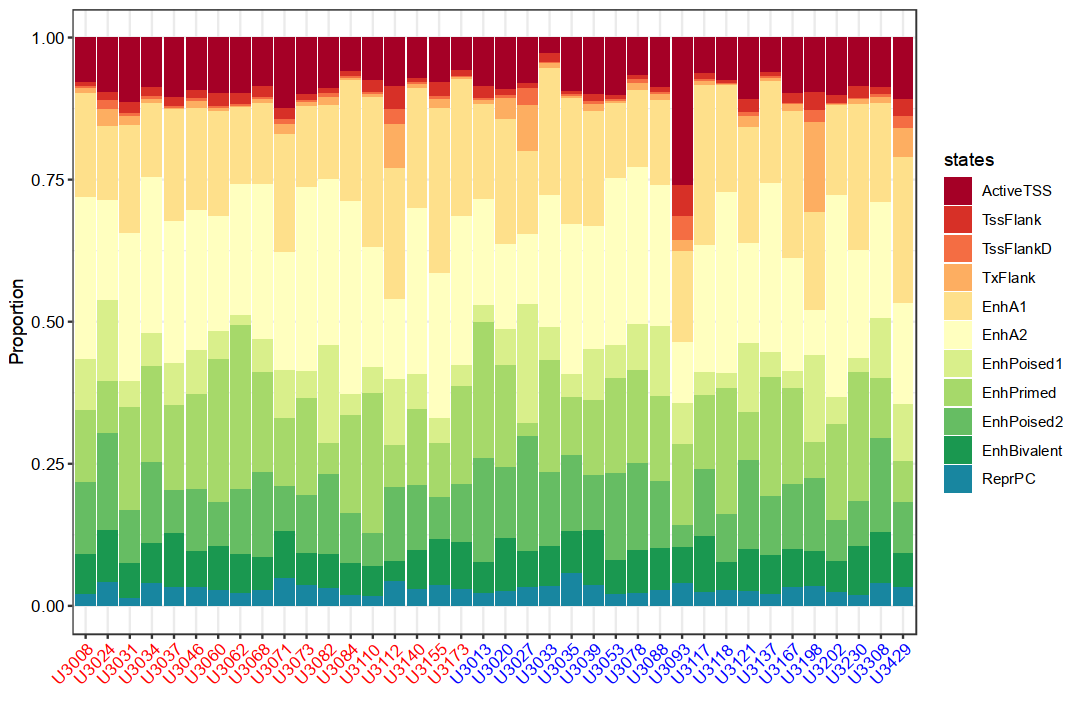

In [71]:
options(repr.plot.height=6,repr.plot.width=9)
p_bar_allpeaks

In [72]:
ggsave(filename = "ChromHMM_allpeaks.pdf",plot = p_bar_allpeaks,width = 9,height =6 )

In [55]:
All_peak_freq_bar  %>% mutate(group = case_when(Group %in% C2_names ~ 'C2',
                                                     Group %in% C3_names ~ 'C3'
                                                    )) -> All_peak_freq_forbox

In [103]:
p_box_allpeak <- ggboxplot(All_peak_freq_forbox,x="group",y="Proportion",add="jitter",add.params=list(shape=21, fill="orange", size=1.5)
         )+geom_signif(comparisons = list(c('C2','C3')),step_increase = 0.1,map_signif_level = F,test = t.test
                      )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")

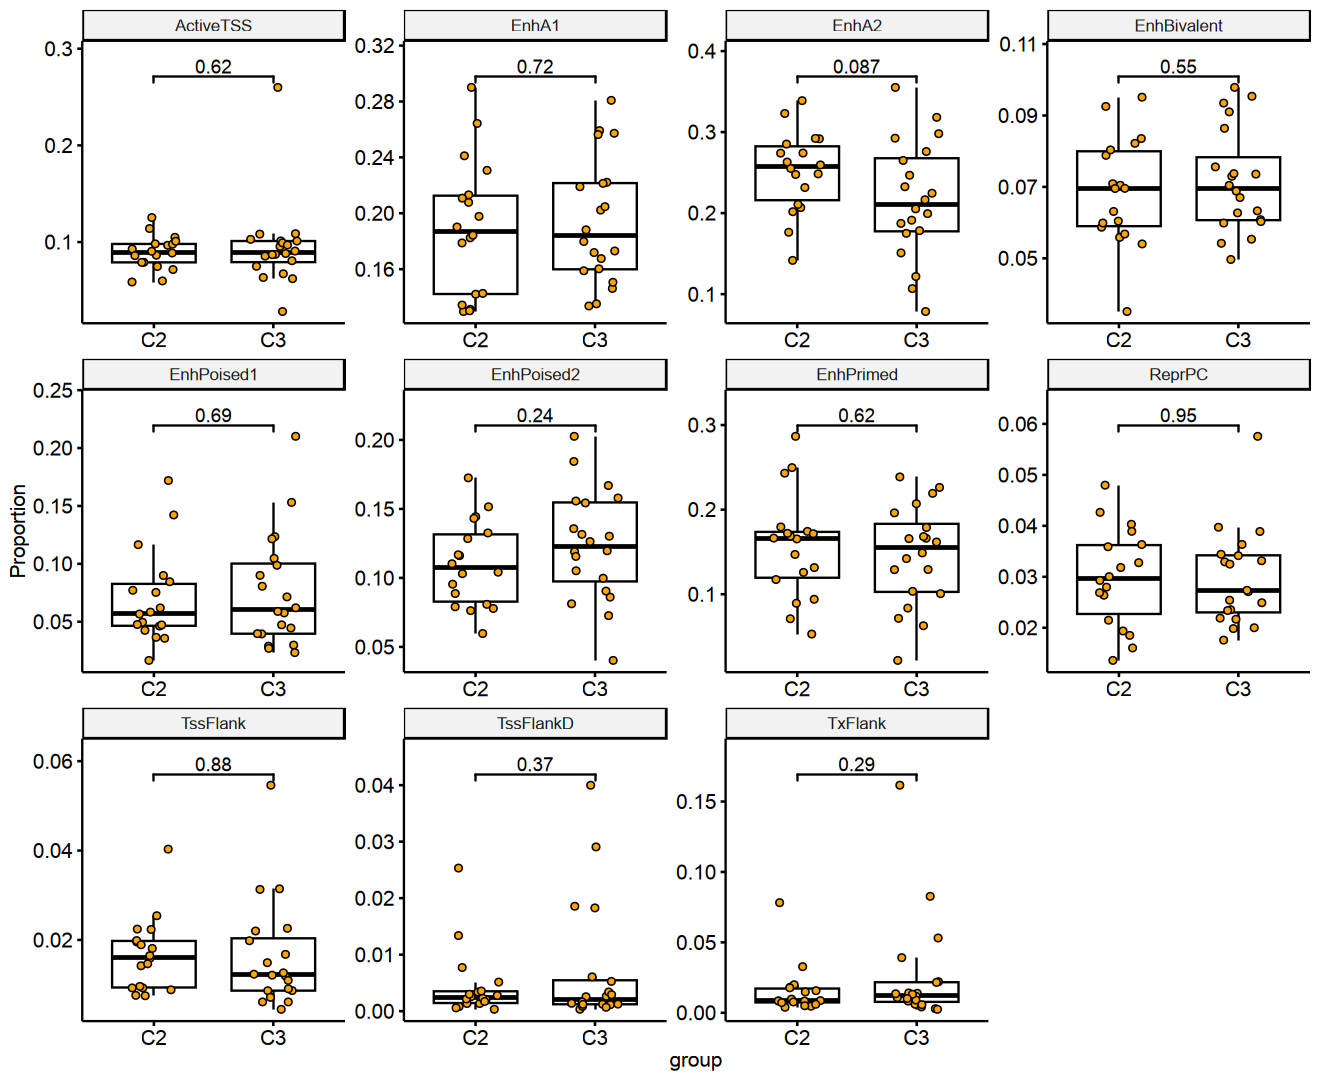

In [104]:
p_box_allpeak

In [135]:
ggsave(filename = "ChromHMM_allpeaks_box.pdf",plot = p_box_allpeak,width = 9,height =6 )

In [ ]:
save.image("C2C3_Peak_freq_box_heatmap.Rdata")

In [1]:
load('C2C3_Peak_freq_box_heatmap.Rdata')